<a href="https://colab.research.google.com/github/UsmanArif169/Machine-Learning-Algorithms-/blob/main/bagging_ensemble_bagging_learning_tool.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [15]:
df = df.iloc[:,1:]
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,setosa
1,3.0,1.4,0.2,setosa
2,3.2,1.3,0.2,setosa
3,3.1,1.5,0.2,setosa
4,3.6,1.4,0.2,setosa


In [16]:
from sklearn.preprocessing import LabelEncoder

In [18]:
encoder = LabelEncoder()
df['species'] = encoder.fit_transform(df['species'])
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [19]:
df = df[['petal_width','petal_length', 'species']]

In [20]:
df.head()

,petal_width,petal_length,species
0,0.2,1.4,0
1,0.2,1.4,0
2,0.2,1.3,0
3,0.2,1.5,0
4,0.2,1.4,0


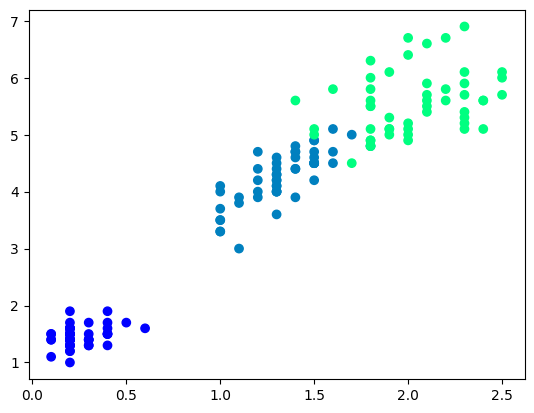

In [23]:
plt.scatter(df['petal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [25]:
df_train = df.iloc[:60,:].sample(10)
df_train

,petal_width,petal_length,species
58,1.3,4.6,1
35,0.2,1.2,0
55,1.3,4.5,1
3,0.2,1.5,0
39,0.2,1.5,0
38,0.2,1.3,0
45,0.3,1.4,0
18,0.3,1.7,0
20,0.2,1.7,0
4,0.2,1.4,0


In [26]:
# Taking only 10 rows for training
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [27]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values


Case 1 - Bagging

In [28]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,petal_width,petal_length,species
3,0.2,1.5,0
54,1.5,4.6,1
8,0.2,1.4,0
54,1.5,4.6,1
21,0.4,1.5,0
21,0.4,1.5,0
8,0.2,1.4,0
24,0.2,1.9,0


In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [36]:
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1,X,y)
#

1.0


In [34]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,petal_width,petal_length,species
40,0.3,1.3,0
24,0.2,1.9,0
3,0.2,1.5,0
21,0.4,1.5,0
54,1.5,4.6,1
30,0.2,1.6,0
49,0.2,1.4,0
3,0.2,1.5,0


In [37]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

1.0


In [38]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,petal_width,petal_length,species
8,0.2,1.4,0
40,0.3,1.3,0
54,1.5,4.6,1
3,0.2,1.5,0
8,0.2,1.4,0
8,0.2,1.4,0
34,0.2,1.5,0
21,0.4,1.5,0


In [39]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

1.0


In [40]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

**Predict**

In [41]:
df_test

,petal_width,petal_length,species
88,1.3,4.1,1
122,2.0,6.7,2
144,2.5,5.7,2
126,1.8,4.8,2
100,2.5,6.0,2


In [42]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]
